## Zero-Shot Scoring

### Imports

In [86]:
import pandas as pd
from transformers import pipeline
import textwrap
import matplotlib.pyplot as plt 

### Setup

In [2]:
df = pd.read_csv("all_papers.csv")

print(f"Amount of Papers: {df.shape[0]}")
print(df.head())

Amount of Papers: 174
                                               Title  \
0  Phantom Formations: Aesthetic Ideology and the...   
1  Immunocytochemical localization of AMPA recept...   
2  Ethnomusicology and Empiricism in the Twenty-F...   
3  Rapid SNP Discovery and Genetic Mapping Using ...   
4  Physiological correlates and emotional specifi...   

                                             Authors  Year  Journal  \
0                                    ['M. Redfield']  1996      160   
1                         ['Wendy Gaza', 'C. Ribak']  1997       17   
2                                      ['J. Becker']  2009       26   
3  ['N. Baird', 'Paul D. Etter', 'T. S. Atwood', ...  2008     3361   
4                     ['M. Benedek', 'C. Kaernbach']  2011      169   

                                            Abstract Extraction Method  
0  Redfield, Marc. Phantom Formations. Aesthetic ...        Method 1.1  
1  Immunocytochemistry was used to study the dist...        Method 1

In [3]:
print("Loading Zero-Shot...")
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
print("Success!")

Loading Zero-Shot...


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Success!


### Labels

In [116]:
# A preliminary label to investigate how much each paper focuses specifically on neuroscience
labels_0 = [
    "This paper focuses on neuroscience, neurobiology, neuronal activity, specific brain regions, and physical cellular mechanisms, including primary empirical studies, systematic reviews, and summaries of neural research."
]

# ACTUAL LABELS

# Subjective Phenomenological Focus vs. Objective Mechanical Focus
labels_1 = [
    "This text focuses on objective, neurobiological, and physiological mechanisms, emphasizing quantitative empirical data, physical measurements, and systematic scientific details.",
    "This text focuses on subjective, phenomenological, or aesthetic experiences, emphasizing psychological perspectives, qualitative frameworks, and emotional interpretation."
]

# Micro-Specific Functions vs. Macro-Bodily Systems
labels_2 = [
    "This text investigates macro-level neurobiology, analyzing large-scale neural networks, holistic brain functionalitiy, regional cortical activity, and functional connectivity using advanced imaging techniques.",
    "This text investigates micro-level neurobiology, analyzing cellular mechanisms, single-unit neuronal activity, synaptic responses, molecular pathways, and neurochemical or genetic interactions."
]

# High Confidence in Physical Explanation vs. Low Confidence in Physical Explanation


label_list = [labels_1, labels_2]


### OPTIONAL - Previewing Zero-Shot's Scoring Mechanism

In [111]:
rand_paper = df.sample(n=1)
a = rand_paper["Abstract"].item()

print(f"Title - {rand_paper["Title"].item()}")
print("Abstract: ")
print(textwrap.fill(a, width=100))

print()
print("Starting Zero-Shot evaluation...")

result = classifier(a, labels_0, multi_label=True)
score = result["scores"][0]

print("Success!")
print(f"Score: {score}")

Title - Organizational Processes in Music
Abstract: 
Music can evoke profound emotions and autobiographical memories. The Bonny Method of Guided Imagery
and Music (BMGIM) is a music therapy approach that uses music-evoked imagery to elicit emotions and
promote self-exploration. To investigate the neural mechanisms of BMGIM, 22 healthy university
students were recruited, of whom 21 were included in the final analysis. Brain activity was measured
using functional near-infrared spectroscopy (fNIRS) during a Music Only session and a BMGIM session
based on a standardized BMGIM music program. Mood changes were assessed using the Profile of Mood
States 2. NIRS data were analyzed using a region-of-interest (ROI)-based approach. Reduced negative
mood scores were observed in both sessions, with depression-dejection showing a significant
reduction only following BMGIM but not after listening to music alone. In the third piece of music,
which was structurally associated with the deepest phase of t

### Scoring based on 3 Scales

In [117]:
def provide_scores(abstract, l_list, paper_scores):
    results = classifier(abstract, l_list, multi_label=True)
    score_dict = dict(zip(results["labels"], results["scores"]))

    val = score_dict[l_list[0]] - score_dict[l_list[1]] 
    #l_list[0]: Objective, Macro
    #l_list[1]: Subjective, Micro
    #Objective - Subjective, Macro - Micro
    
    paper_scores.append(val)

In [118]:
all_paper_scores = []
i = 0

print("Starting Zero-Shot evaluation...")
for j, r in df.iterrows():
    abstr = r["Abstract"]
    year = r["Year"]
    temp = [year]

    for ll in label_list:
        provide_scores(abstr, ll, temp)

    all_paper_scores.append(temp)

    if i % 50 == 0:
        print(f"{i} out of {len(df)} papers evaluated...")

    i += 1

print(f"Success! All {len(all_paper_scores)} papers scored")

Starting Zero-Shot evaluation...
0 out of 174 papers evaluated...
50 out of 174 papers evaluated...
100 out of 174 papers evaluated...
150 out of 174 papers evaluated...
Success! All 174 papers scored


   Year     Focus  Magnitude
0  1996 -0.603641  -0.037179
1  1997  0.033286  -0.419309
2  2009 -0.126621  -0.402511
3  2008 -0.073271  -0.468653
4  2011  0.120526  -0.123334


<Figure size 1000x1000 with 0 Axes>

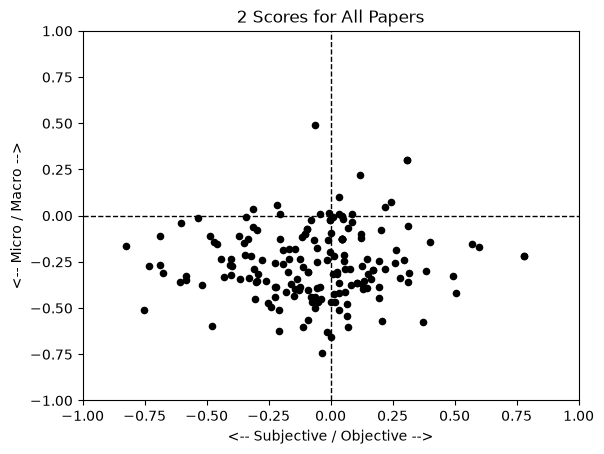

In [130]:
df_scores = pd.DataFrame(all_paper_scores)
df_scores = df_scores.rename(columns={0: "Year", 1: "Focus", 2: "Magnitude"})
print(df_scores.head())

#df_scores.to_csv("all_papers_scores")

plt.figure(figsize=(10,10))

df_scores.plot.scatter(x="Focus", y="Magnitude", color="black")

plt.title("2 Scores for All Papers")
plt.xlabel("<-- Subjective / Objective -->")
plt.ylabel("<-- Micro / Macro -->")

plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.axvline(0, color="black", linewidth=1, linestyle="--")

plt.xlim(-1,1)
plt.ylim(-1,1)

plt.show()

### Graphs Throughout the Decades

#### 5 Dataframes for 5 Decades

In [127]:
df_scores_80s = df_scores[(df_scores["Year"] >= 1980) & (df_scores["Year"] < 1990)].copy()
df_scores_90s = df_scores[(df_scores["Year"] >= 1990) & (df_scores["Year"] < 2000)].copy()
df_scores_00s = df_scores[(df_scores["Year"] >= 2000) & (df_scores["Year"] < 2010)].copy()
df_scores_10s = df_scores[(df_scores["Year"] >= 2010) & (df_scores["Year"] < 2020)].copy()
df_scores_20s = df_scores[(df_scores["Year"] >= 2020)].copy()
decades = [df_scores_80s,
           df_scores_90s,
           df_scores_00s,
           df_scores_10s,
           df_scores_20s]

print(f"Papers in the 80s: {len(df_scores_80s)}")
print(f"Papers in the 90s: {len(df_scores_90s)}")
print(f"Papers in the 00s: {len(df_scores_00s)}")
print(f"Papers in the 10s: {len(df_scores_10s)}")
print(f"Papers in the 20s: {len(df_scores_20s)}")
print(f"All together: {len(df_scores_80s) + len(df_scores_90s) + len(df_scores_00s) + len(df_scores_10s) + len(df_scores_20s)}")

Papers in the 80s: 20
Papers in the 90s: 16
Papers in the 00s: 18
Papers in the 10s: 56
Papers in the 20s: 64
All together: 174


#### Displaying the Decades

<Figure size 1000x1000 with 0 Axes>

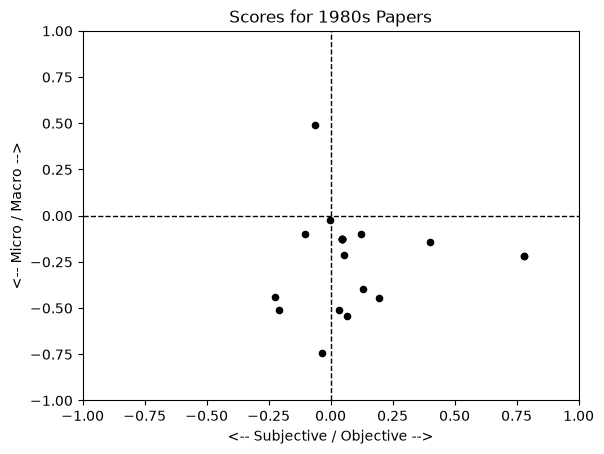

<Figure size 1000x1000 with 0 Axes>

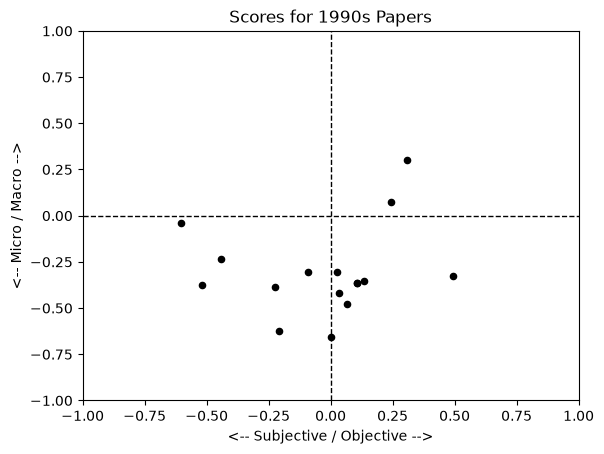

<Figure size 1000x1000 with 0 Axes>

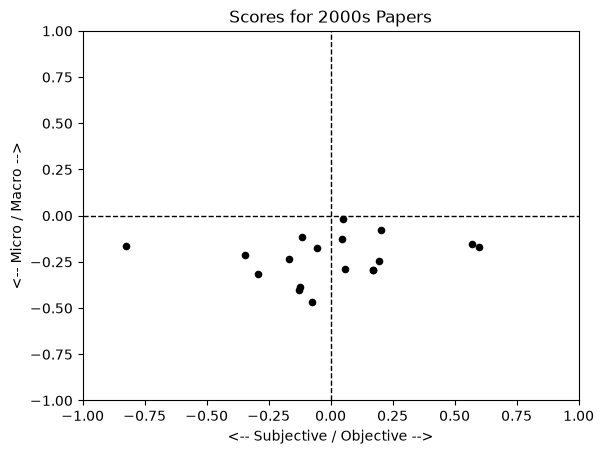

<Figure size 1000x1000 with 0 Axes>

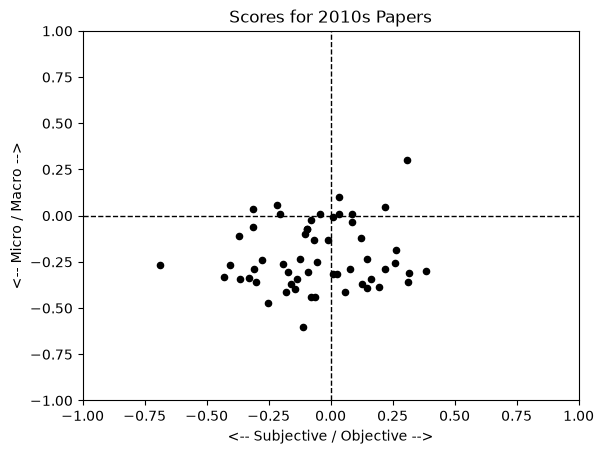

<Figure size 1000x1000 with 0 Axes>

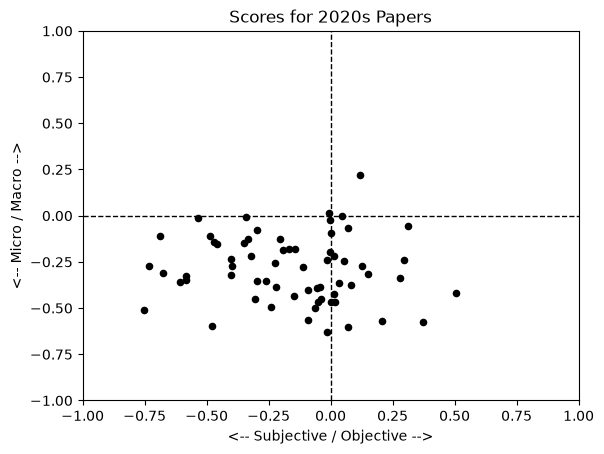

In [129]:
for i in range(len(decades)):
    plt.figure(figsize=(10,10))

    decades[i].plot.scatter(x="Focus", y="Magnitude", color="black")

    plt.title(f"Scores for {1980 + i * 10}s Papers")
    plt.xlabel("<-- Subjective / Objective -->")
    plt.ylabel("<-- Micro / Macro -->")

    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    plt.axvline(0, color="black", linewidth=1, linestyle="--")

    plt.xlim(-1,1)
    plt.ylim(-1,1)

    plt.show()